In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle
import seaborn as sns
import h5py
import time
import scipy.sparse as sp
import yaml
import gc
from matplotlib import gridspec

from datetime import datetime

import anndata as an
import scanpy as sc

sc.settings.verbosity = 3

In [2]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/sample_1_adata_basename_deg.parquet"

df = pd.read_parquet(fpath)
print(f"Raw data shape: {df.shape=}")
df = df.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

df.head()

Raw data shape: df.shape=(417312, 8)
CPU times: user 234 ms, sys: 68.8 ms, total: 303 ms
Wall time: 474 ms


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
7769,endothelial_cells,MIR4454,0.200185,18.774147,0.841336,0.999989,0.000285,0.0
10261,endothelial_cells,RNU6-570P,0.035120,16.763958,0.971984,0.999989,0.000050,0.0
9989,endothelial_cells,ENSG00000286030.2,0.042144,16.398457,0.966384,0.999989,0.000060,0.0
11036,endothelial_cells,PSPC1P2,0.021072,16.307268,0.983188,0.999989,0.000030,0.0
10780,endothelial_cells,MIR5003,0.024584,15.523371,0.980387,0.999989,0.000035,0.0


In [3]:
df['group'].value_counts()

group
endothelial_cells            52164
fibroblasts                  52164
hematopoietic_progenitors    52164
hsc                          52164
innate_lymphoid_cells        52164
lymphoid_cells               52164
mesenchymal_cells            52164
myeloid_cells                52164
Name: count, dtype: int64

/tmp/ipykernel_3952035/4012490067.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf['label'] = pdf['group'].apply(lambda x: x.replace("_", " "))


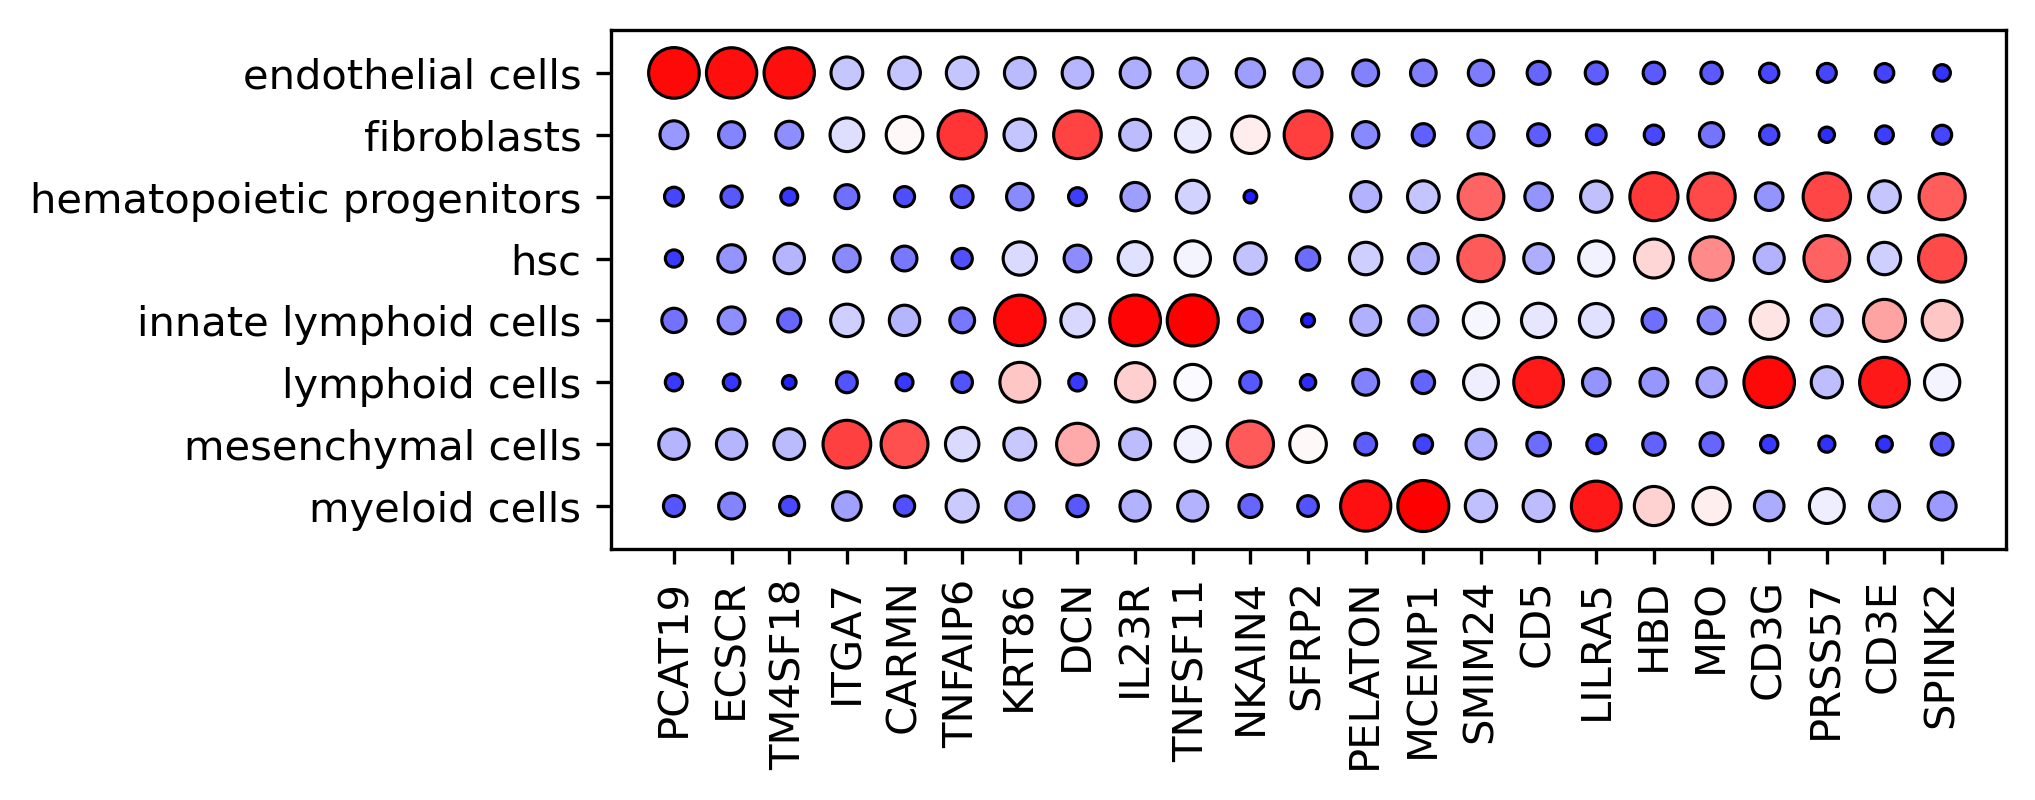

In [4]:
top_n_genes = 3

# filter out genes only expressed in a few cells, robust DEG
pct_nz_group = 0.15
gdf = df[df['pct_nz_group'] > pct_nz_group].copy()
gdf = gdf.groupby('group').head(top_n_genes)

deg_genes = gdf['names'].unique()

# now filter the full frame for these genes
pdf = df[df['names'].isin(deg_genes)]

pdf['label'] = pdf['group'].apply(lambda x: x.replace("_", " "))
pdf = pdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 2.25

sns.scatterplot(
    data=pdf,
    x='names',
    y='label',
    hue='logfoldchanges',
    size='logfoldchanges',
    sizes=(0, 150),
    ec='k',
    lw=0.75,
    legend=False,
    palette='bwr',
)

plt.margins(y=0.1)
plt.gca().tick_params(axis='x', rotation=90)
plt.ylabel("")
plt.xlabel("")

ax = plt.gca()
y_labels = ax.get_yticklabels()
y_ticks = ax.get_yticks()

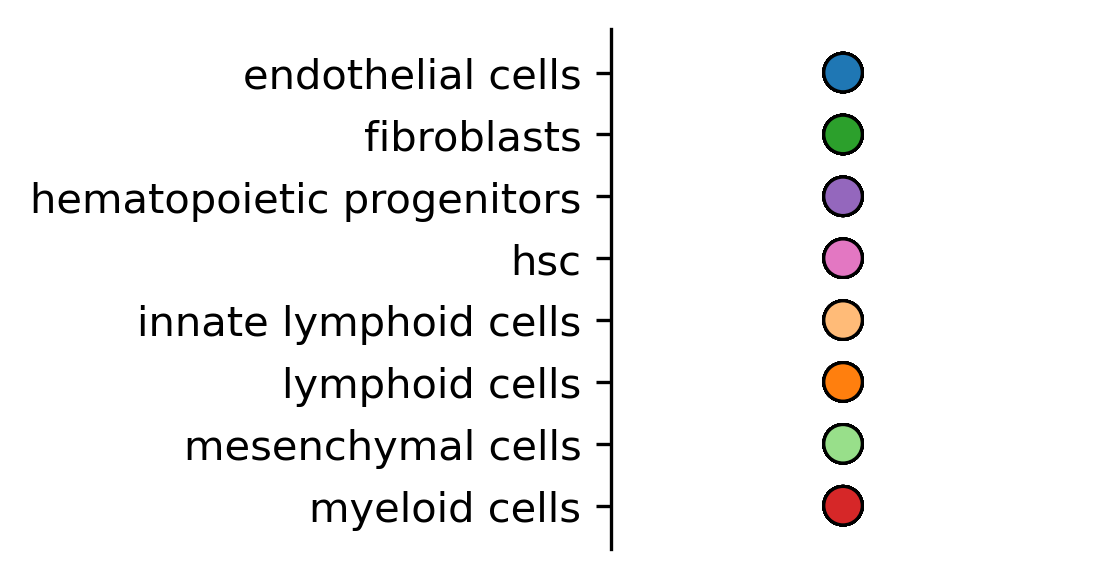

In [5]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2, 2.25

palette = {
    "endothelial_cells": "#1f77b4",       # blue
    "fibroblasts": "#2ca02c",             # green
    "hematopoietic_progenitors": "#9467bd",  # purple
    "hsc": "#e377c2",                     # pink
    "innate_lymphoid_cells": "#ffbb78",  # peach
    "lymphoid_cells": "#ff7f0e",         # orange
    "mesenchymal_cells": "#98df8a",      # light green
    "myeloid_cells": "#d62728"           # red
}

sns.scatterplot(
    data=pdf,
    x=[1] * len(pdf),
    y='label',
    hue='group',
    s=85,
    ec='k',
    lw=0.75,
    legend=False,
    palette=palette,
)

plt.ylabel("")
plt.xticks([])
plt.margins(y=0.1)
sns.despine(bottom=True)

ax = plt.gca()

ax.set_facecolor('none')            # make axis (plot area) transparent
ax.figure.set_facecolor('none')     # make figure (outer area) transparent

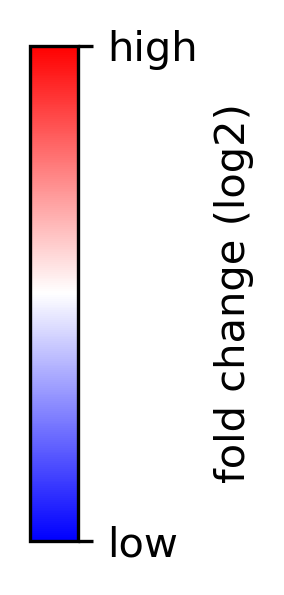

In [6]:
def make_colorbar(cmap='viridis', 
                  width=0.2,
                  height=2.75, 
                  title='', 
                  orientation='vertical', 
                  tick_labels=['low', 'high']):
  
    a = np.array([[0, 1]])  # Dummy data for the image
    plt.figure(figsize=(width, height))
    img = plt.imshow(a, cmap=cmap)
    plt.gca().set_visible(False)  # Hide the axes of the image
    cax = plt.axes([0.1, 0.2, 0.8, 0.6])  # Define the colorbar position

    ticks = np.linspace(0, 1, len(tick_labels)) 
    cbar = plt.colorbar(
        orientation='vertical',
        cax=cax,
        label=title,
        ticks=ticks
    )

    cbar.ax.set_yticklabels(tick_labels)

make_colorbar('bwr', title='fold change (log2)')
# make_colorbar('viridis', title='expression')

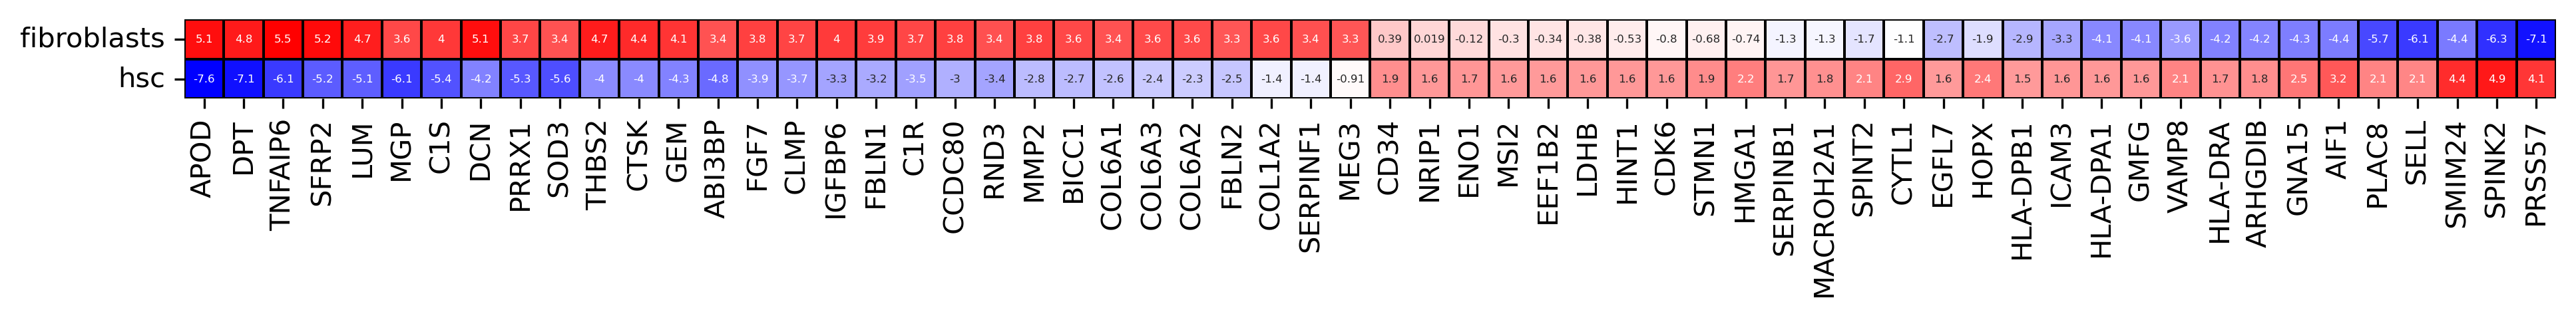

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

top_n_genes = 30
pct_nz_group = 0.35

# Select top genes
gdf = df[(df['pct_nz_group'] > pct_nz_group) & df['group'].isin(['fibroblasts', 'hsc'])].copy()
gdf = gdf.groupby('group').head(top_n_genes)
deg_genes = gdf['names'].unique()

# Filter full frame
pdf = df[df['names'].isin(deg_genes) & df['group'].isin(['fibroblasts', 'hsc'])].copy()
pdf = pdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

# Pivot for heatmap (genes as rows, groups as columns)
heat_data = pdf.pivot(index='names', columns='group', values='logfoldchanges')
heat_data = heat_data.fillna(0)  # or np.nan if you prefer masking

heat_data['sort_key'] = heat_data['fibroblasts'] - heat_data['hsc']
heat_data = heat_data.sort_values(by='sort_key', ascending=False)
heat_data = heat_data.drop(columns='sort_key')

# Plot heatmap
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 13, 5

sns.heatmap(
    heat_data.T,
    cmap='bwr',
    linewidths=0.5,
    linecolor='k',
    cbar=False,
    # cbar_kws={"label": "logFC"},
    annot=True,
    square=True,
    annot_kws={'fontsize' : 4},
    xticklabels=True,
    yticklabels=['fibroblasts', 'hsc'],
)

plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [8]:
# break

In [9]:
print(df.head().to_string())

                   group              names    scores  logfoldchanges     pvals  pvals_adj  pct_nz_group  pct_nz_reference
7769   endothelial_cells            MIR4454  0.200185       18.774147  0.841336   0.999989      0.000285               0.0
10261  endothelial_cells          RNU6-570P  0.035120       16.763958  0.971984   0.999989      0.000050               0.0
9989   endothelial_cells  ENSG00000286030.2  0.042144       16.398457  0.966384   0.999989      0.000060               0.0
11036  endothelial_cells            PSPC1P2  0.021072       16.307268  0.983188   0.999989      0.000030               0.0
10780  endothelial_cells            MIR5003  0.024584       15.523371  0.980387   0.999989      0.000035               0.0


In [10]:
df['group'].unique()

array(['endothelial_cells', 'fibroblasts', 'hematopoietic_progenitors',
       'hsc', 'innate_lymphoid_cells', 'lymphoid_cells',
       'mesenchymal_cells', 'myeloid_cells'], dtype=object)

# Load marker genes

In [11]:
def load_pathway(fpath):
    """
    Loads an Enrichr-like database file into a boolean DataFrame.

    Args:
        fpath (str): Path to the Enrichr-like database file.

    Returns:
        pandas.DataFrame: A boolean DataFrame where:
            - Index: Genes
            - Columns: Pathways
            - Values: True if the gene is in the pathway, False otherwise.
    """

    result = []
    with open(fpath,  encoding='utf-8') as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity
    return df

fpath = "../../resources/Tabula_Sapiens.txt"
tab = load_pathway(fpath)
print(f"{tab.shape=}")
tab.head()

tab.shape=(1509, 469)


label,Bladder-bladder Urothelial Cell,Bladder-capillary Endothelial Cell,Bladder-endothelial Cell Of Lymphatic Vessel,Bladder-fibroblast,Bladder-macrophage,Bladder-mast Cell,Bladder-myofibroblast Cell,Bladder-nk Cell,Bladder-pericyte Cell,Bladder-plasma Cell,...,Thymus-dn4 Thymocyte,Thymus-innate Lymphoid Cell,Thymus-myeloid Dendritic Cell,Thymus-naive Regulatory T Cell,Thymus-t Follicular Helper Cell,Tongue-schwann Cell,Vasculature-artery Endothelial Cell,Vasculature-lymphatic Endothelial Cell,Eye-adipocyte,Eye-retinal Ganglion Cell
GDF15,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
RPS8,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
RPL21,True,True,True,True,False,True,True,True,True,True,...,True,True,True,True,True,False,True,True,True,True
RPS9,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,False
RPS6,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [12]:
canonical_to_finegrained = {
    'endothelial_cells': [
        'Bladder-capillary Endothelial Cell',
        'Lung-capillary Endothelial Cell',
        'Muscle-endothelial Cell Of Vascular Tree',
        'Kidney-endothelial Cell',
        'Vasculature-endothelial Cell',
        'Spleen-endothelial Cell',
        'Liver-endothelial Cell'
    ],

    'fibroblasts': [
        'Bladder-fibroblast',
        'Large Intestine-fibroblast',
        'Liver-fibroblast',
        'Heart-fibroblast Of Cardiac Tissue',
        'Pancreas-fibroblast',
        'Fat-fibroblast',
        'Salivary Gland-fibroblast',
        'Trachea-fibroblast'
    ],

    'hematopoietic_progenitors': [
        'Bone Marrow-myeloid Progenitor',
        'Blood-myeloid Progenitor',
        'Prostate-erythroid Progenitor'
    ],

    'hsc': [
        'Blood-hematopoietic Stem Cell',
        'Bone Marrow-hematopoietic Stem Cell',
        'Spleen-hematopoietic Stem Cell',
        'Lymph Node-hematopoietic Stem Cell'
    ],

    'innate_lymphoid_cells': [
        'Lymph Node-innate Lymphoid Cell',
        'Spleen-innate Lymphoid Cell',
        'Thymus-innate Lymphoid Cell'
    ],

    'lymphoid_cells': [
        'Blood-cd4-positive, Alpha-Beta T Cell',
        'Blood-cd8-positive, Alpha-Beta T Cell',
        'Lymph Node-cd4-positive Alpha-Beta T Cell',
        'Lymph Node-cd8-positive Alpha-Beta T Cell',
        'Spleen-cd4-positive, Alpha-Beta Memory T Cell',
        'Spleen-cd8-positive, Alpha-Beta T Cell'
    ],

    'mesenchymal_cells': [
        'Muscle-mesenchymal Stem Cell',
        'Fat-mesenchymal Stem Cell'
    ],

    'myeloid_cells': [
        'Blood-monocyte',
        'Lung-macrophage',
        'Spleen-macrophage',
        'Liver-macrophage',
        'Bone Marrow-monocyte',
        'Blood-neutrophil',
        'Blood-classical Monocyte',
        'Lung-dendritic Cell'
    ]
}

group='endothelial_cells'
len(present_markers)=88
                  group     names  logfoldchanges      pvals_adj  pct_nz_group  pct_nz_reference
1     endothelial_cells     CLDN5        6.567920   0.000000e+00      0.586197          0.023174
273   endothelial_cells      SELE        6.546268   0.000000e+00      0.191821          0.005558
12    endothelial_cells       VWF        6.282347   0.000000e+00      0.477586          0.017730
19    endothelial_cells     PTPRB        6.259843   0.000000e+00      0.450850          0.012577
415   endothelial_cells      FCN3        5.614327   0.000000e+00      0.154233          0.009300
0     endothelial_cells    TM4SF1        5.577568   0.000000e+00      0.691158          0.094450
256   endothelial_cells     ACKR1        5.220870   0.000000e+00      0.207561          0.018416
9     endothelial_cells      EMCN        5.145666   0.000000e+00      0.499407          0.037357
78    endothelial_cells       KDR        4.992610   0.000000e+00      0.31067

/home/cstansbu/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


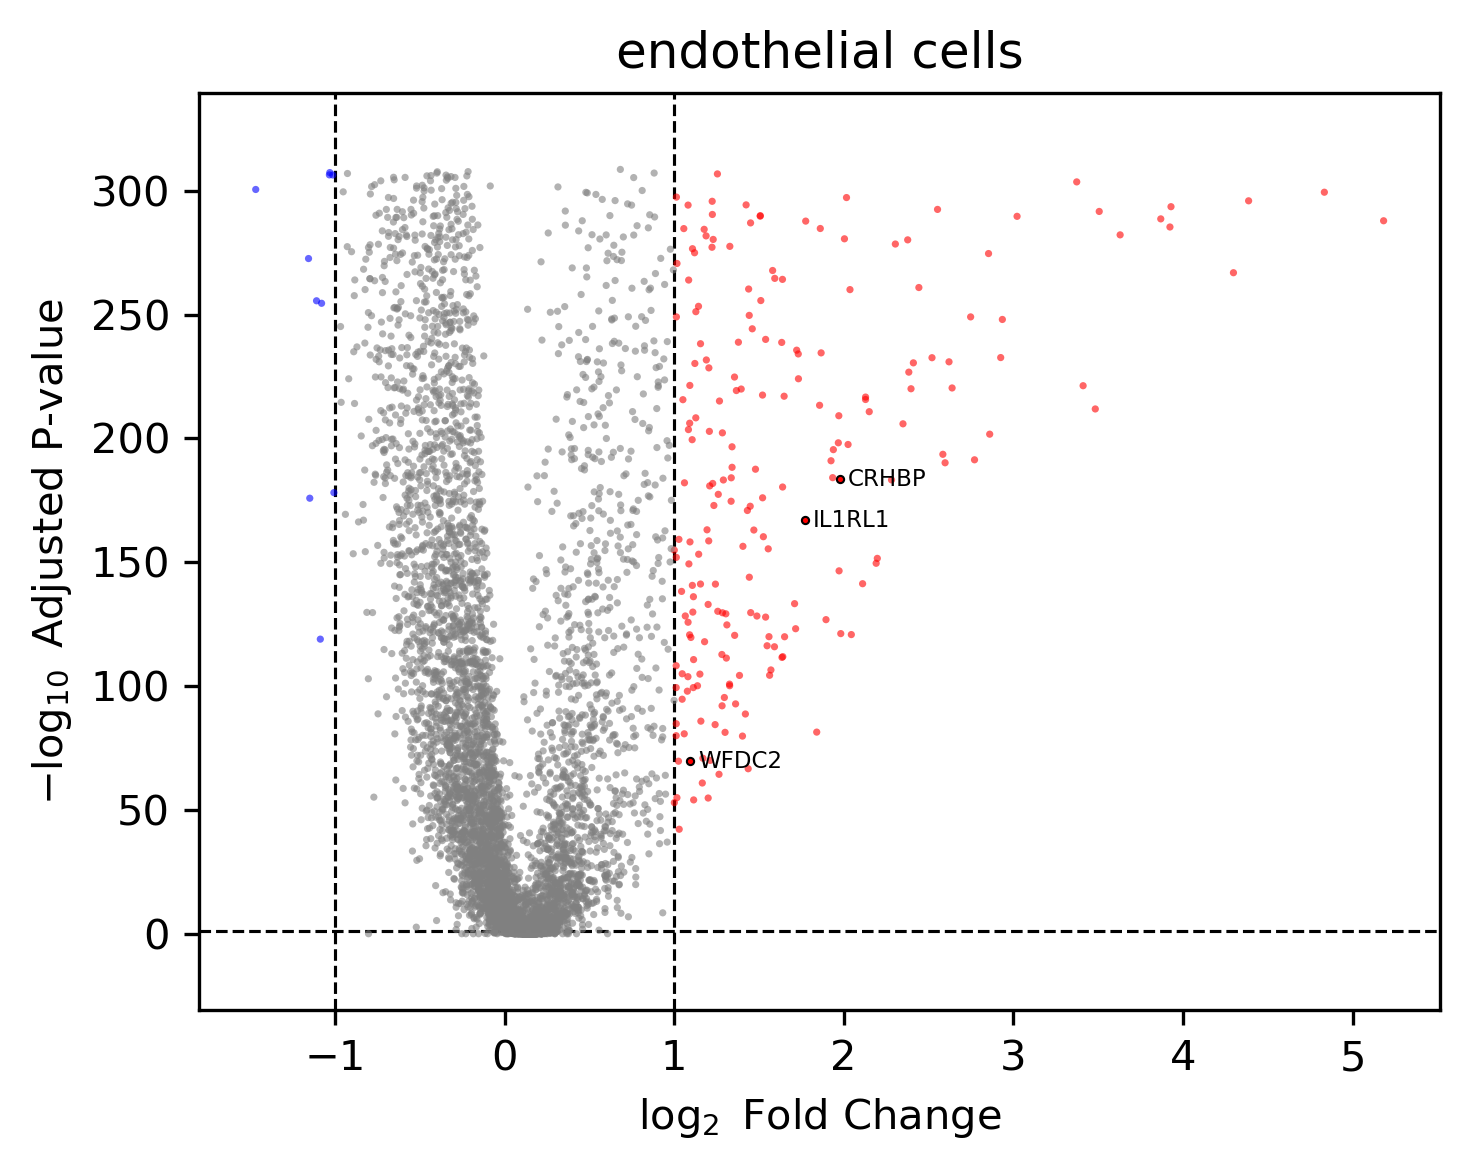

/home/cstansbu/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


group='fibroblasts'
len(present_markers)=94
             group     names  logfoldchanges      pvals_adj  pct_nz_group  pct_nz_reference
52211  fibroblasts     SFRP2        5.201144   0.000000e+00      0.384805          0.021007
52164  fibroblasts       DCN        5.117887   0.000000e+00      0.843120          0.175285
52174  fibroblasts      APOD        5.114668   0.000000e+00      0.566190          0.068842
52166  fibroblasts       LUM        4.726838   0.000000e+00      0.656335          0.081666
52255  fibroblasts    CXCL14        4.346769   0.000000e+00      0.338310          0.033749
52427  fibroblasts     MFAP5        4.285472   0.000000e+00      0.217645          0.017130
52170  fibroblasts       C1S        4.031579   0.000000e+00      0.621020          0.092492
52206  fibroblasts    IGFBP6        3.996523   0.000000e+00      0.440090          0.062818
52171  fibroblasts     FBLN1        3.937587   0.000000e+00      0.633945          0.105067
52176  fibroblasts    CCDC80        

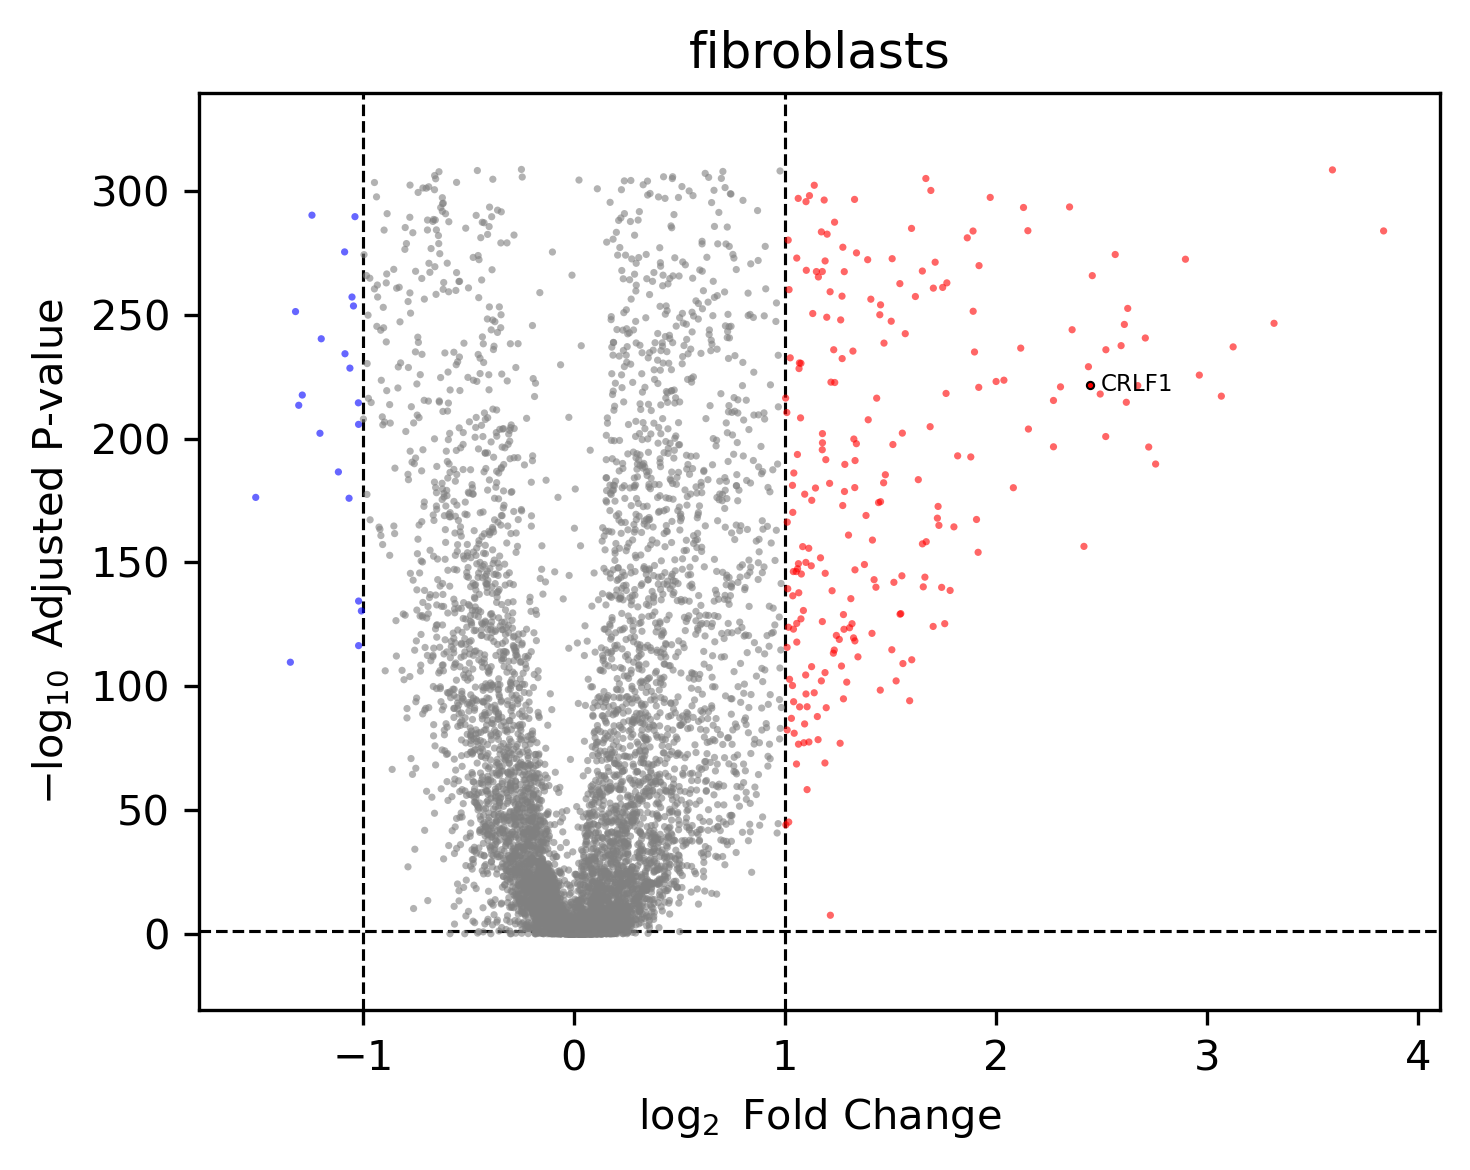

/home/cstansbu/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


group='hematopoietic_progenitors'
len(present_markers)=51
                            group     names  logfoldchanges      pvals_adj  pct_nz_group  pct_nz_reference
104718  hematopoietic_progenitors       HBD        5.392189   0.000000e+00      0.256295          0.012424
106193  hematopoietic_progenitors       CA1        4.766729   0.000000e+00      0.134160          0.010887
104614  hematopoietic_progenitors      AHSP        3.243951   0.000000e+00      0.301272          0.030406
104648  hematopoietic_progenitors     HEMGN        3.195496   0.000000e+00      0.293803          0.033128
104328  hematopoietic_progenitors      NPM1        2.558331   0.000000e+00      0.927850          0.679088
104330  hematopoietic_progenitors     HINT1        2.493093   0.000000e+00      0.911224          0.631546
105036  hematopoietic_progenitors       HBB        2.443751   0.000000e+00      0.280602          0.084538
105374  hematopoietic_progenitors      GMPR        2.414051   0.000000e+00      0.2146

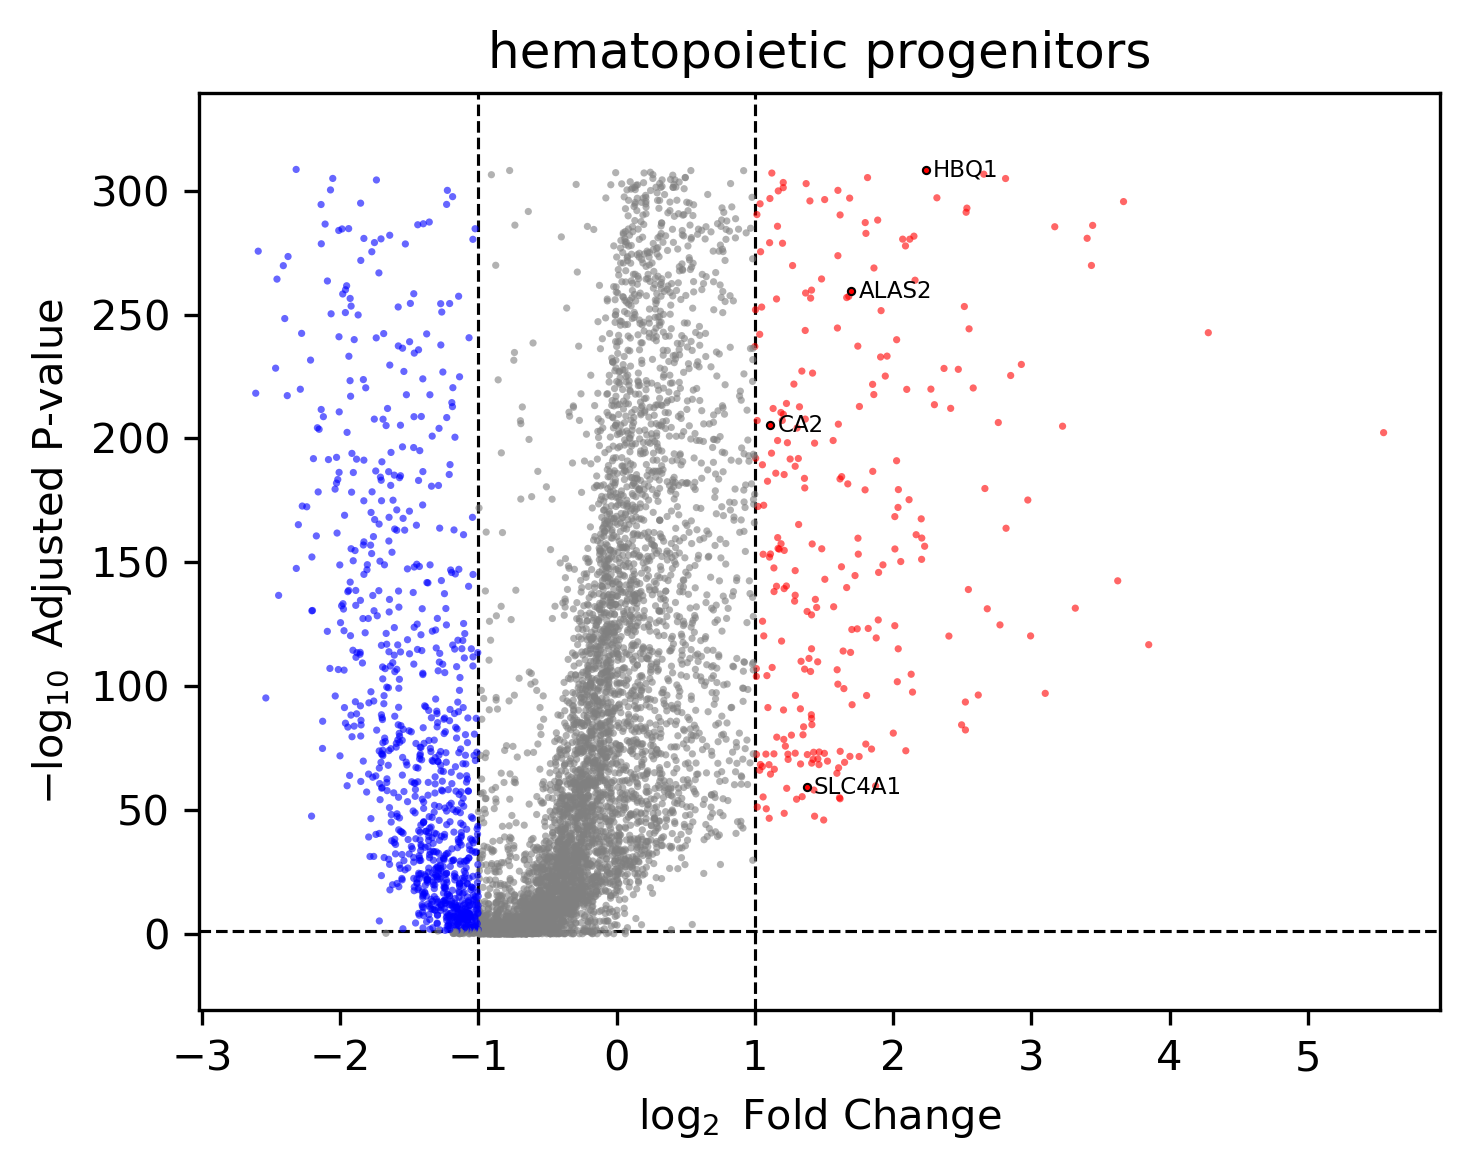

/home/cstansbu/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


group='hsc'
len(present_markers)=12
       group     names  logfoldchanges      pvals_adj  pct_nz_group  pct_nz_reference
156966   hsc       MPO        2.883200   0.000000e+00      0.131971          0.021264
156716   hsc      HBA2        1.879270   0.000000e+00      0.255788          0.101527
156520   hsc   HLA-DRA        1.728555   0.000000e+00      0.556454          0.274403
156537   hsc  HLA-DPA1        1.574108   0.000000e+00      0.510175          0.248152
156494   hsc    EEF1B2        1.552560   0.000000e+00      0.760955          0.637373
156496   hsc      NPM1        1.465330   0.000000e+00      0.802848          0.689351
156538   hsc      CD74        1.451432   0.000000e+00      0.683762          0.462069
156498   hsc   HNRNPA1        1.414979   0.000000e+00      0.793202          0.685184
159036   hsc     S100B        1.334272   2.845057e-32      0.057625          0.023553
156543   hsc      SOX4        1.327604   0.000000e+00      0.575103          0.334947
156517   hsc     G

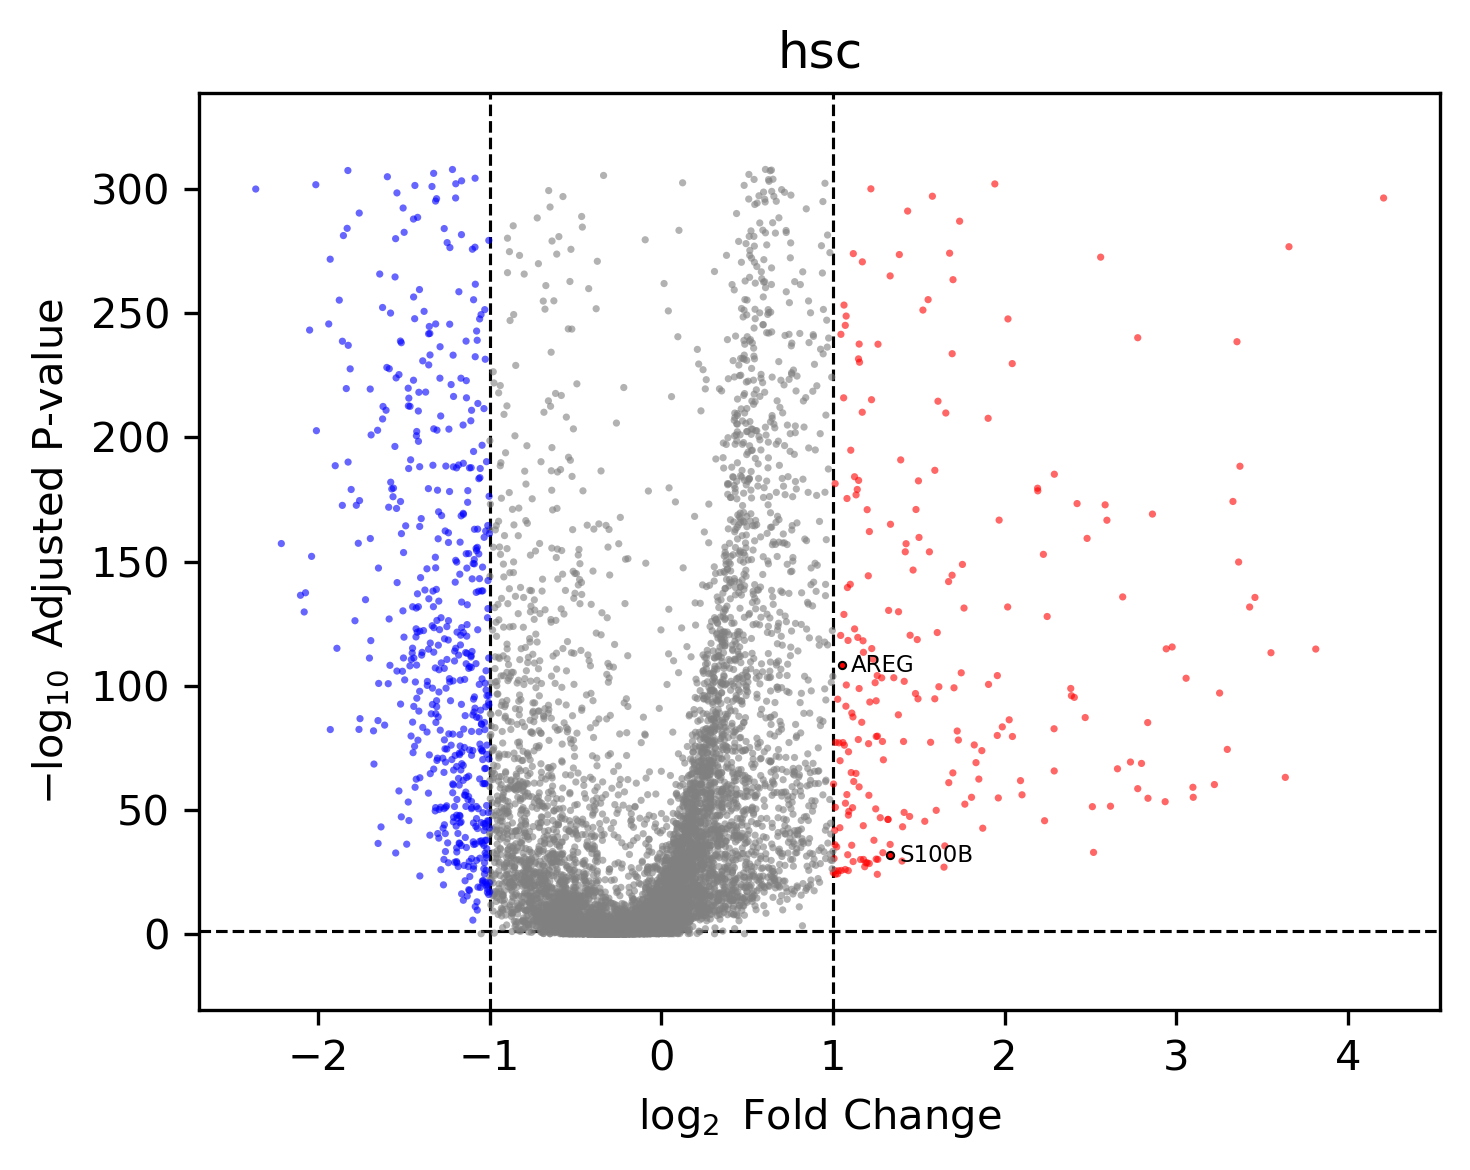

/home/cstansbu/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


group='innate_lymphoid_cells'
len(present_markers)=10
                        group    names  logfoldchanges  pvals_adj  pct_nz_group  pct_nz_reference
208657  innate_lymphoid_cells     IL7R        3.899821        0.0      0.617464          0.142027
208696  innate_lymphoid_cells     AREG        2.823268        0.0      0.392355          0.101263
208668  innate_lymphoid_cells     CD69        2.664941        0.0      0.512142          0.164344
208660  innate_lymphoid_cells     SRGN        2.362090        0.0      0.811940          0.416868
208675  innate_lymphoid_cells  TNFAIP3        2.178985        0.0      0.553185          0.245130
208755  innate_lymphoid_cells    DUSP2        2.112848        0.0      0.346469          0.139510
208684  innate_lymphoid_cells    CXCR4        2.014540        0.0      0.529947          0.230507
208702  innate_lymphoid_cells   NFKBIA        1.434303        0.0      0.689533          0.543234
208708  innate_lymphoid_cells    ZFP36        1.374474        0.

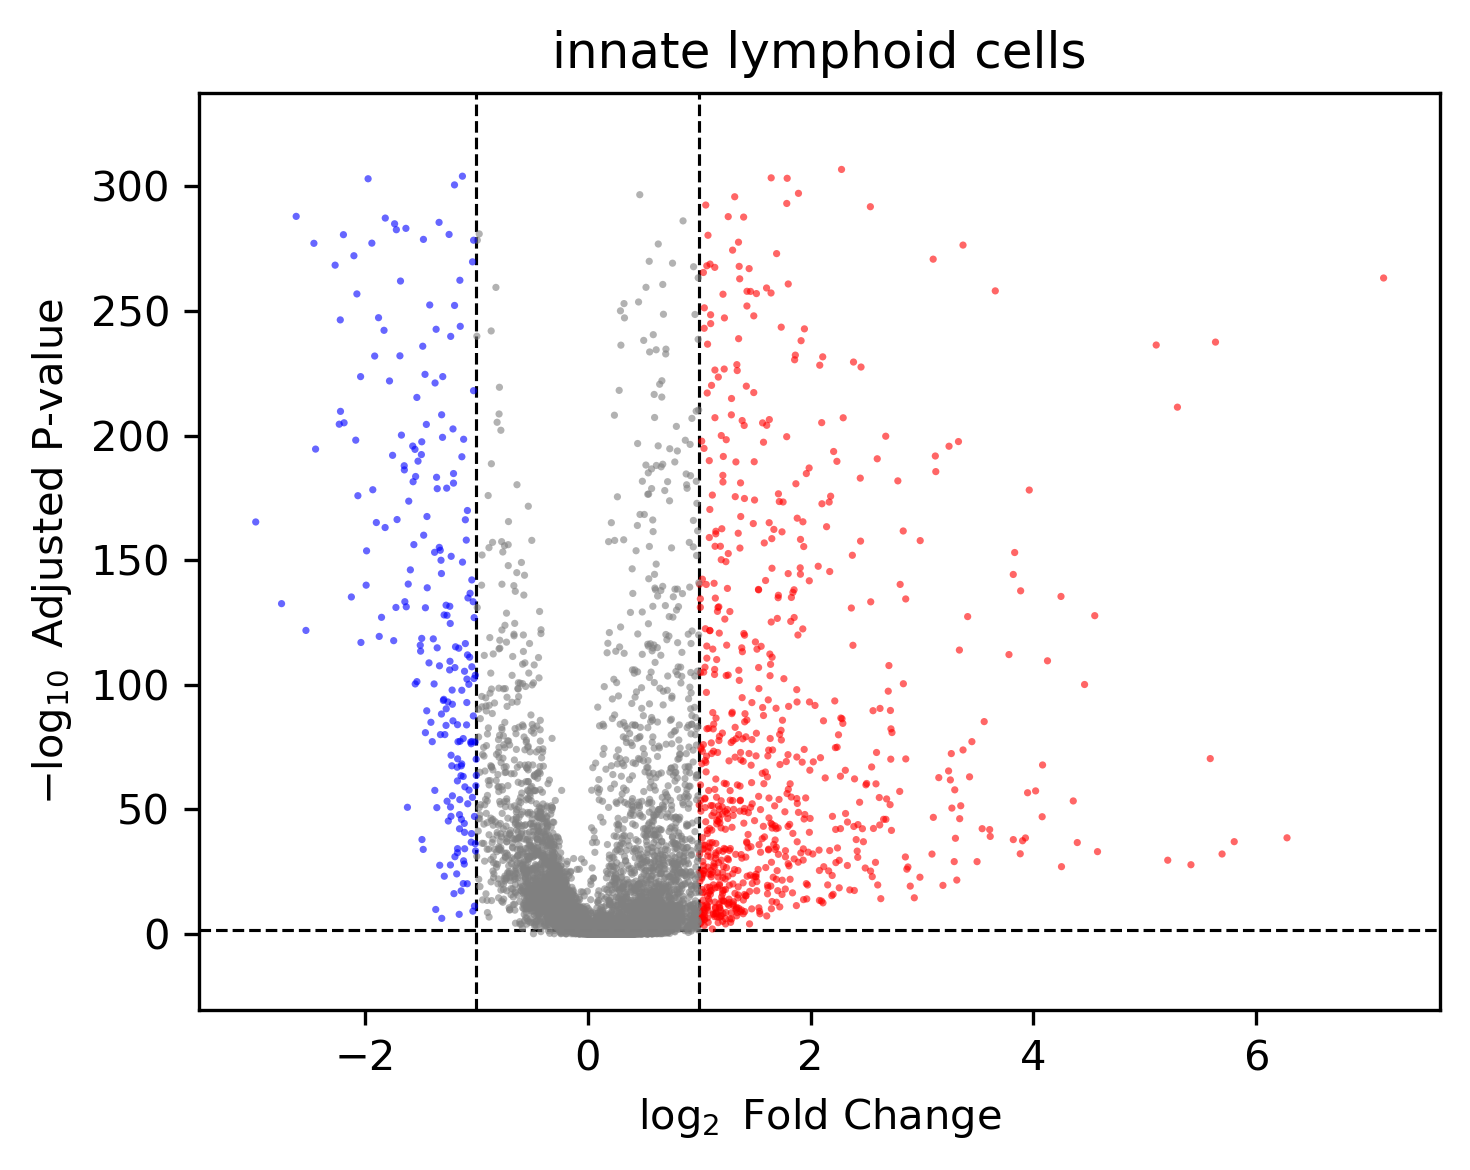

/home/cstansbu/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


group='lymphoid_cells'
len(present_markers)=91
                 group     names  logfoldchanges  pvals_adj  pct_nz_group  pct_nz_reference
261082  lymphoid_cells      GZMA        5.265259        0.0      0.240083          0.012170
260823  lymphoid_cells       LTB        4.923262        0.0      0.650030          0.070216
260995  lymphoid_cells      CCL5        4.772400        0.0      0.325767          0.031053
260842  lymphoid_cells      IL7R        4.566328        0.0      0.556174          0.060349
261102  lymphoid_cells      GNLY        4.299808        0.0      0.246098          0.034150
261031  lymphoid_cells      NKG7        4.099141        0.0      0.316961          0.061601
260846  lymphoid_cells      CD69        3.937826        0.0      0.568855          0.082642
260826  lymphoid_cells     CXCR4        3.662050        0.0      0.679153          0.138465
260822  lymphoid_cells      CD52        3.487229        0.0      0.765758          0.191354
260862  lymphoid_cells      IL32 

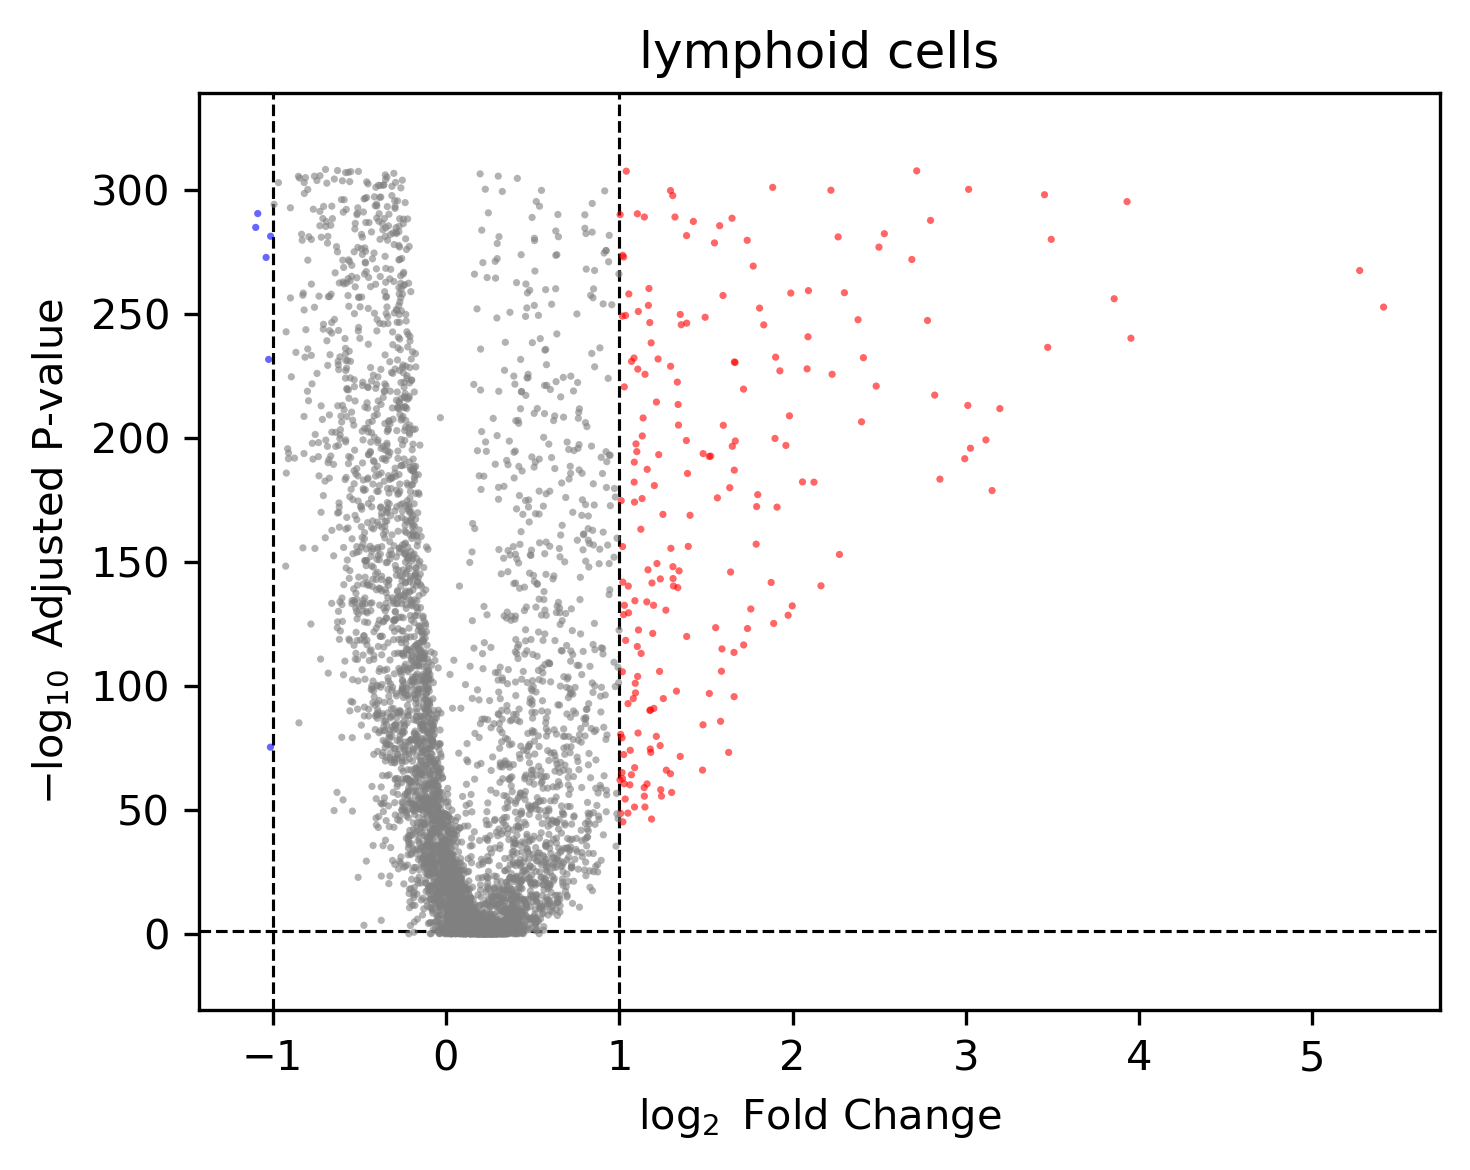

/home/cstansbu/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


group='mesenchymal_cells'
len(present_markers)=9
                    group    names  logfoldchanges  pvals_adj  pct_nz_group  pct_nz_reference
312994  mesenchymal_cells   IGFBP5        2.852010        0.0      0.508305          0.117566
313003  mesenchymal_cells  SPARCL1        1.974103        0.0      0.635750          0.254571
312998  mesenchymal_cells      DCN        1.939438        0.0      0.625830          0.222265
313337  mesenchymal_cells    ADH1B        1.925717        0.0      0.214045          0.065706
313062  mesenchymal_cells   COL6A3        1.656621        0.0      0.413115          0.155590
313056  mesenchymal_cells   COL4A1        1.606672        0.0      0.460105          0.206385
313081  mesenchymal_cells     EGR1        1.513690        0.0      0.467160          0.256546
313035  mesenchymal_cells    TIMP3        1.440741        0.0      0.582395          0.298157
313052  mesenchymal_cells   IFITM3        1.242371        0.0      0.688860          0.468006



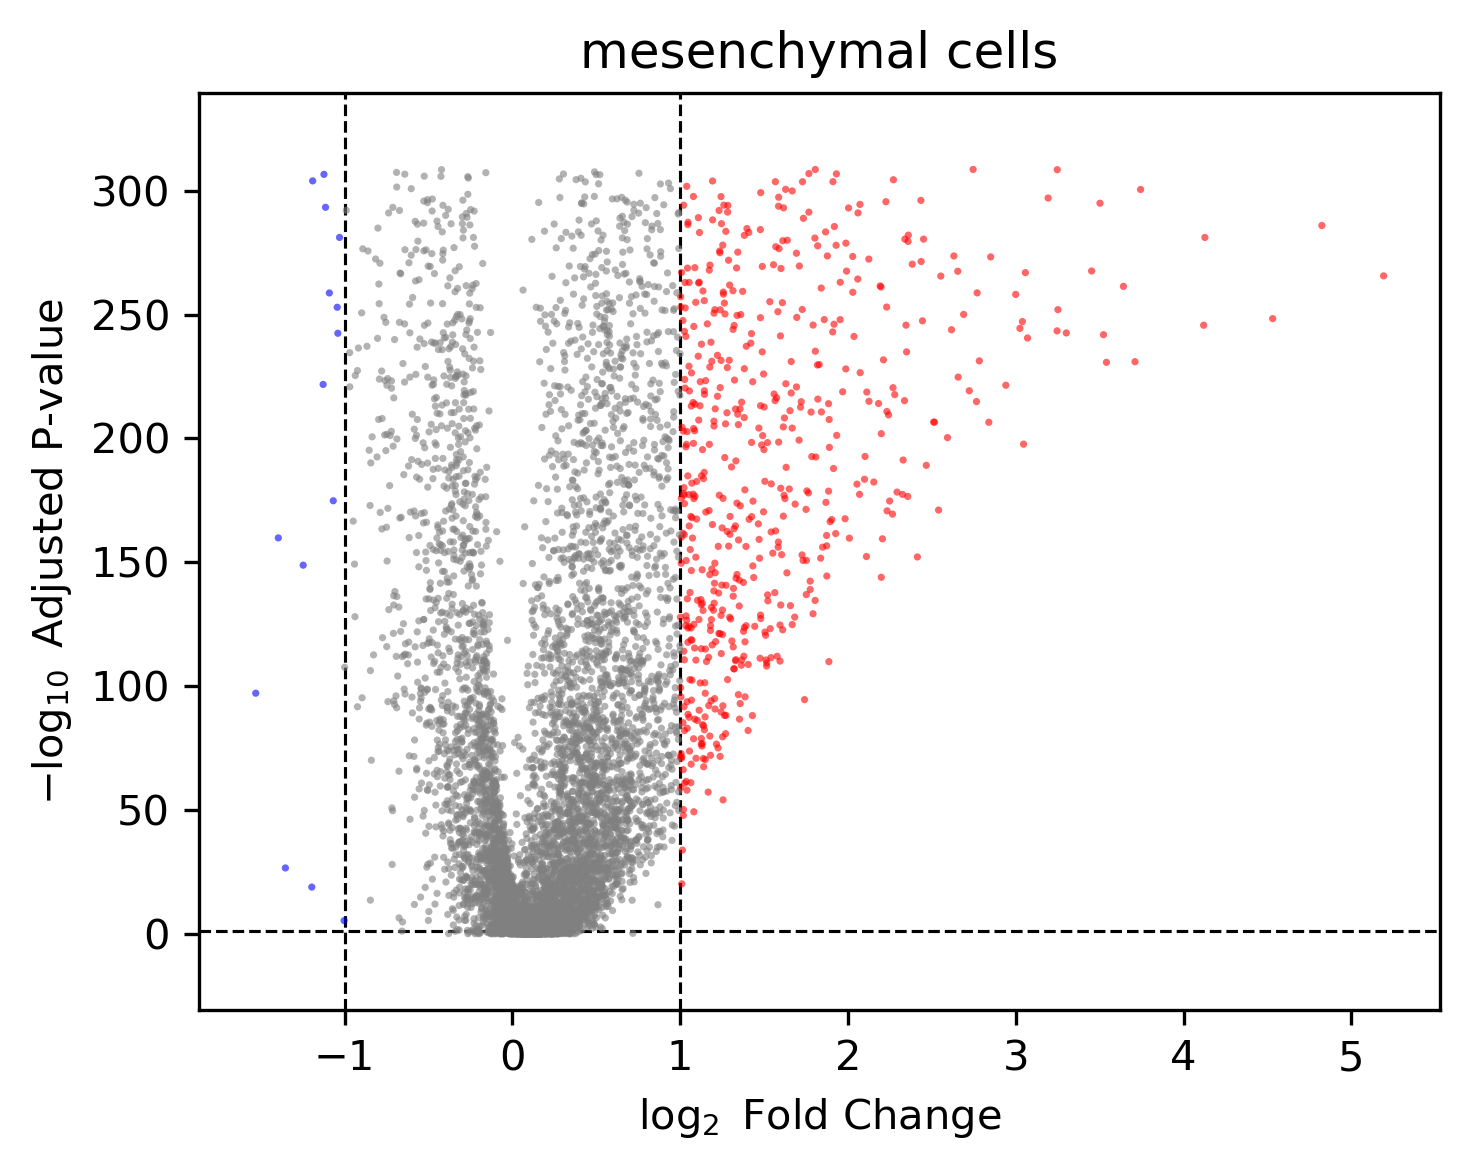

/home/cstansbu/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


group='myeloid_cells'
len(present_markers)=81
                group     names  logfoldchanges      pvals_adj  pct_nz_group  pct_nz_reference
365200  myeloid_cells      FCN1        6.310612   0.000000e+00      0.347571          0.012962
365298  myeloid_cells   S100A12        6.225296   0.000000e+00      0.253982          0.008715
365158  myeloid_cells      MNDA        6.083007   0.000000e+00      0.485511          0.018493
365150  myeloid_cells       LYZ        5.633084   0.000000e+00      0.604914          0.088012
365227  myeloid_cells      FPR1        5.622313   0.000000e+00      0.306262          0.008602
365154  myeloid_cells    S100A9        5.547428   0.000000e+00      0.555918          0.081059
365160  myeloid_cells    S100A8        5.514523   0.000000e+00      0.494392          0.062345
365183  myeloid_cells   SLC11A1        5.484876   0.000000e+00      0.395952          0.020111
365148  myeloid_cells    TYROBP        5.467069   0.000000e+00      0.679481          0.091474
3651

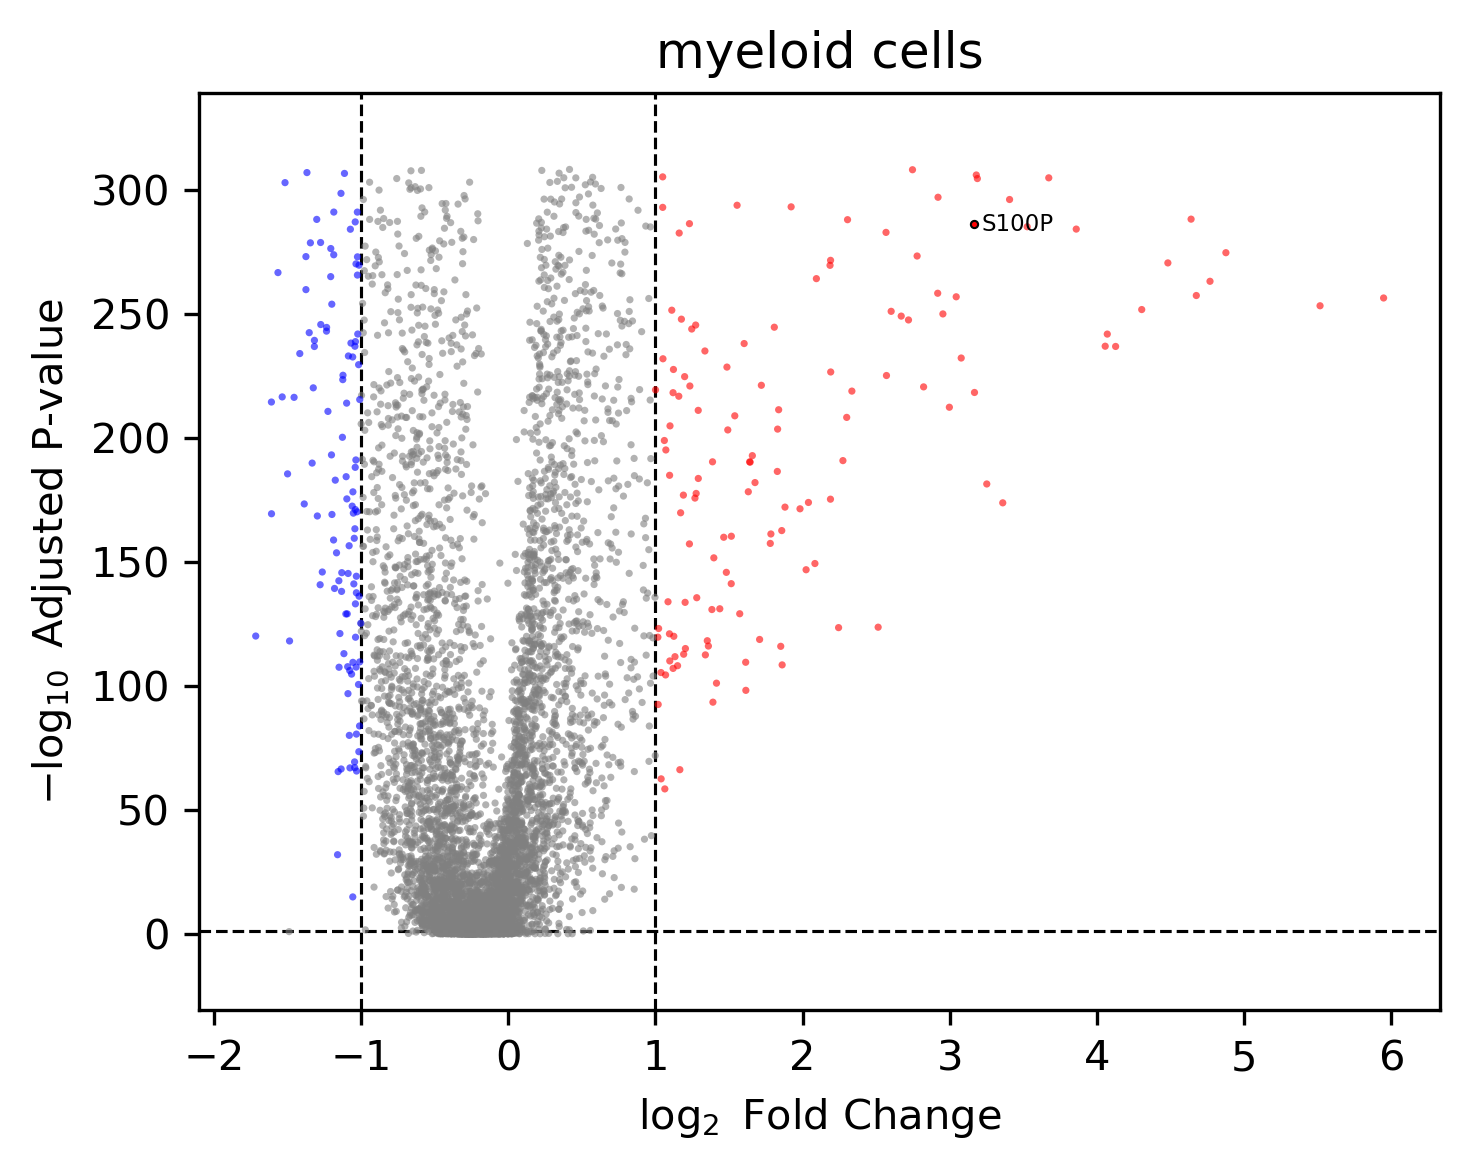

In [13]:
# Set thresholds
logfc_thresh = 1
fdr_thresh = 0.05
pct_nz_group = 0.05

marker_df = []

# Plot one volcano plot per group
groups = df['group'].unique()

for group in groups:
    sub = df[df['group'] == group].copy()
    sub = sub[sub['pct_nz_group'] > pct_nz_group]
    sub['-log10(padj)'] = -np.log10(sub['pvals_adj'])

    # Add significance status
    sub['significant'] = 'not sig'
    sub.loc[(sub['pvals_adj'] < fdr_thresh) & (sub['logfoldchanges'] > logfc_thresh), 'significant'] = 'up'
    sub.loc[(sub['pvals_adj'] < fdr_thresh) & (sub['logfoldchanges'] < -logfc_thresh), 'significant'] = 'down'

    # marker genes (get tabula sapeins genes)
    tab_columns = canonical_to_finegrained[group]
    marker_genes = tab[tab[tab_columns].any(axis=1)].index

    # Plot
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = 5, 4
    
    sns.scatterplot(
        data=sub,
        x='logfoldchanges',
        y='-log10(padj)',
        hue='significant',
        palette={'not sig': 'gray', 'up': 'red', 'down': 'blue'},
        linewidth=0,
        alpha=0.6,
        s=3,
        legend=False,
    )

    # Annotate significantly upregulated marker genes with finite values
    up_genes = sub[sub['logfoldchanges'] > logfc_thresh]
    present_markers = set(marker_genes).intersection(up_genes['names'])
    print(f"{group=}")
    print(f"{len(present_markers)=}")

    present_markers_frame = up_genes[up_genes['names'].isin(present_markers)]
    present_markers_frame = present_markers_frame[['group', 'names', 'logfoldchanges', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference']]

    marker_df.append(present_markers_frame)
    
    print(present_markers_frame.to_string())
    print()


    sub['-log10(padj)'] = np.where(~np.isfinite(sub['-log10(padj)']),sub['-log10(padj)'].max(), sub['-log10(padj)'] )

    for gene in present_markers:
        row = sub[sub['names'] == gene].iloc[0]
        logfc = row['logfoldchanges']
        neglog10_padj = row['-log10(padj)']
        if (
            logfc > logfc_thresh and 
            row['pvals_adj'] < fdr_thresh and
            np.isfinite(logfc) and 
            np.isfinite(neglog10_padj)
        ):
            plt.text(
                logfc + 0.05,
                neglog10_padj,
                gene,
                fontsize=5.5,
                color='black',
                ha='left',
                va='center'
            )
            # Add black-edged point
            plt.scatter(
                logfc,
                neglog10_padj,
                color='red',        # match significance color
                edgecolor='k',
                linewidth=0.5,
                s=3,
                zorder=3
            )
    
    # Aesthetic settings
    plt.axhline(-np.log10(fdr_thresh), color='black', linestyle='--', lw=0.75, zorder=0)
    plt.axvline(logfc_thresh, color='black', linestyle='--', lw=0.75, zorder=0)
    plt.axvline(-logfc_thresh, color='black', linestyle='--', lw=0.75, zorder=0)
    plt.title(group.replace("_", " "))

    plt.xlabel(r"$\log_2$ Fold Change")
    plt.ylabel(r"$-\log_{10}$ Adjusted P-value")
    
    plt.margins(y=0.1)
    plt.tight_layout()
    plt.show()
    # break


marker_df = pd.concat(marker_df)
outpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/analysis/basename_marker_genes.csv"
marker_df.to_csv(outpath, index=False)

# Genes from the literature

In [15]:
import pandas as pd

# Load literature gene annotations
fpath = "../../resources/literature_genes.csv"
ldf = pd.read_csv(fpath)
print(f"Loaded literature gene table: {ldf.shape}")

# Output file
out_file = "/scratch/indikar_root/indikar1/shared_data/hematokytos/analysis/literature_gene_report_basename_deg.txt"
with open(out_file, "w") as f:
    # Write header
    f.write("Hematopoietic Marker Gene Report\n")
    f.write("Generated from single-cell differential expression analysis\n")
    f.write("=" * 60 + "\n\n")

    for _, row in ldf.iterrows():
        gene = row['Gene/Factor']
        if gene not in df['names'].unique():
            continue

        # Print and write gene section header
        header = f"==================== {gene} ====================\n"
        meta = (
            f"{'Cell types':<12}: {row['Cell Type(s)']}\n"
            f"{'Citations':<12}: {row['Source(s)']}\n"
            f"{'Annotation':<12}: {row['Context/Function']}\n"
        )

        # Subset and format DE results
        sub = df[df['names'] == gene][[
            'group', 'logfoldchanges', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference'
        ]].sort_values(by='logfoldchanges', ascending=False).copy()

        # Format numerical output
        sub['logfoldchanges'] = sub['logfoldchanges'].map("{:.3f}".format)
        sub['pvals_adj'] = sub['pvals_adj'].map("{:.1e}".format)
        sub['pct_nz_group'] = sub['pct_nz_group'].map("{:.3f}".format)
        sub['pct_nz_reference'] = sub['pct_nz_reference'].map("{:.3f}".format)

        # Rename columns for clarity
        sub.columns = ['Group', 'logFC', 'FDR', '%>0 (group)', '%>0 (ref)']
        table = sub.to_string(index=False)

        # Output
        block = header + meta + "\n" + table + "\n\n" + ("-" * 60) + "\n\n"
        print(block)
        f.write(block)

print(f"Report written to {out_file}")


Loaded literature gene table: (245, 4)
==================== ABCB7 ====================
Cell types  : MDS cells
Citations   : Cortés-López 2023 (Cell Stem Cell)
Annotation  : Gene potentially mis-spliced in SF3B1-mutant MDS, causing ring sideroblast formation

                    Group  logFC      FDR %>0 (group) %>0 (ref)
    innate_lymphoid_cells  0.410  8.1e-03       0.133     0.122
hematopoietic_progenitors  0.249  0.0e+00       0.227     0.116
           lymphoid_cells  0.241  4.2e-01       0.117     0.124
        mesenchymal_cells  0.200  8.2e-02       0.123     0.122
                      hsc  0.138  1.8e-55       0.171     0.121
            myeloid_cells  0.097  1.9e-41       0.141     0.119
              fibroblasts -0.320  2.7e-75       0.100     0.127
        endothelial_cells -0.485 3.6e-208       0.086     0.131

------------------------------------------------------------


==================== ACE ====================
Cell types  : Human dermal fibroblasts (HDFs)
Citation